### Кластеризация

### Загрузка библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import joblib

### Загрузка датасета

In [2]:
df = pd.read_csv("patient_segmentation_dataset.csv")

### Задаем ключевые переменные

In [3]:
FEATURES = ['Age', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits', 'Avg_Billing_Amount']

In [4]:
X = df[FEATURES].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Метод локтя

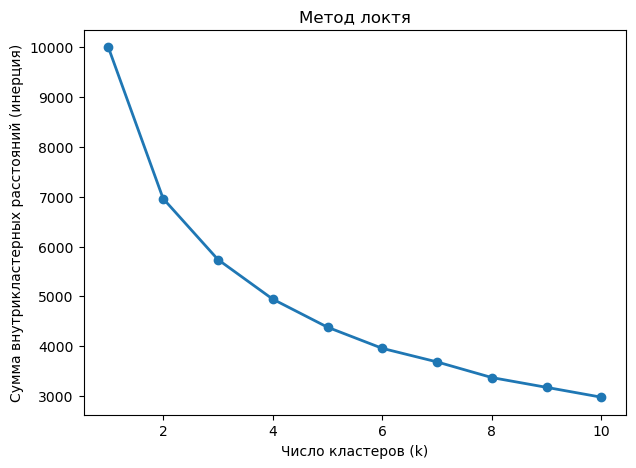

In [5]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), inertia, marker='o', linewidth=2)
plt.title("Метод локтя")
plt.xlabel("Число кластеров (k)")
plt.ylabel("Сумма внутрикластерных расстояний (инерция)")
plt.show()

Прям явный сгиб не наблюдается, я думаю он есть в точке 6

### Проведем методы кластеризации

In [6]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=0.5, min_samples=2)
df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

agg = AgglomerativeClustering(n_clusters=6, linkage='ward')
df['cluster_agg'] = agg.fit_predict(X_scaled)

Выведем метрики

In [7]:
def print_metrics(labels, name):
    if len(set(labels)) < 2:
        print(f"{name}: недостаточно кластеров")
        return
    sil = silhouette_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    print(f"{name} - Sil: {sil:.3f}   CH: {ch:.1f}")

print_metrics(df['cluster_kmeans'], "KMeans")
print_metrics(df['cluster_dbscan'], "DBSCAN")
print_metrics(df['cluster_agg'], "Agglomerative")

KMeans - Sil: 0.245   CH: 609.4
DBSCAN - Sil: -0.177   CH: 15.7
Agglomerative - Sil: 0.208   CH: 521.7


In [8]:
print("\nKMeans кластеры:")
print(df.groupby('cluster_kmeans')[FEATURES].mean().round(2))
print("\nDBSCAN кластеры:")
print(df.groupby('cluster_dbscan')[FEATURES].mean().round(2))
print("\nAgglomerativeClustering кластеры:")
print(df.groupby('cluster_agg')[FEATURES].mean().round(2))


KMeans кластеры:
                  Age    BMI  Num_Chronic_Conditions  Annual_Visits  \
cluster_kmeans                                                        
0               51.89  42.45                    1.00           5.67   
1               54.47  25.56                    1.06           3.30   
2               69.44  31.22                    2.57           5.77   
3               30.59  29.38                    0.02           2.50   
4               68.73  30.38                    2.54           7.57   
5               52.88  27.19                    1.01           9.65   

                Avg_Billing_Amount  
cluster_kmeans                      
0                          4177.86  
1                          3971.67  
2                          8535.61  
3                          2549.34  
4                          2848.04  
5                          3988.03  

DBSCAN кластеры:
                  Age    BMI  Num_Chronic_Conditions  Annual_Visits  \
cluster_dbscan              

## Графически выведем методы

### KMeans

Наиболее простой, но в то же время достаточно неточный метод кластеризации в классической реализации. Он разбивает множество элементов векторного пространства на заранее известное число кластеров k.

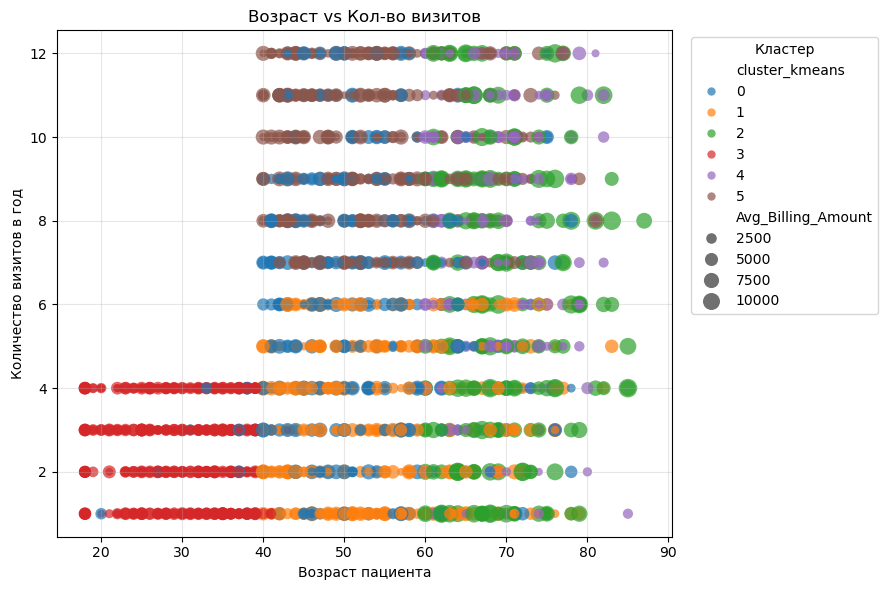

In [9]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Age',
    y='Annual_Visits',
    hue='cluster_kmeans',
    palette='tab10',
    size='Avg_Billing_Amount',          # размер точки = кол-во визитов
    sizes=(30, 180),               # диапазон размеров
    alpha=0.7,
    edgecolor='none'
)

plt.title("Возраст vs Кол-во визитов")
plt.xlabel("Возраст пациента")
plt.ylabel("Количество визитов в год")
plt.legend(title="Кластер", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### DBSCAN

DBSCAN ,как следует из названия, оперирует плотностью данных. На вход он просит уже знакомую матрицу близости и два загадочных параметра — радиус $\epsilon$-окрестности и количество соседей.

C:\Users\Muham\AppData\Local\Temp\ipykernel_30584\2152774236.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


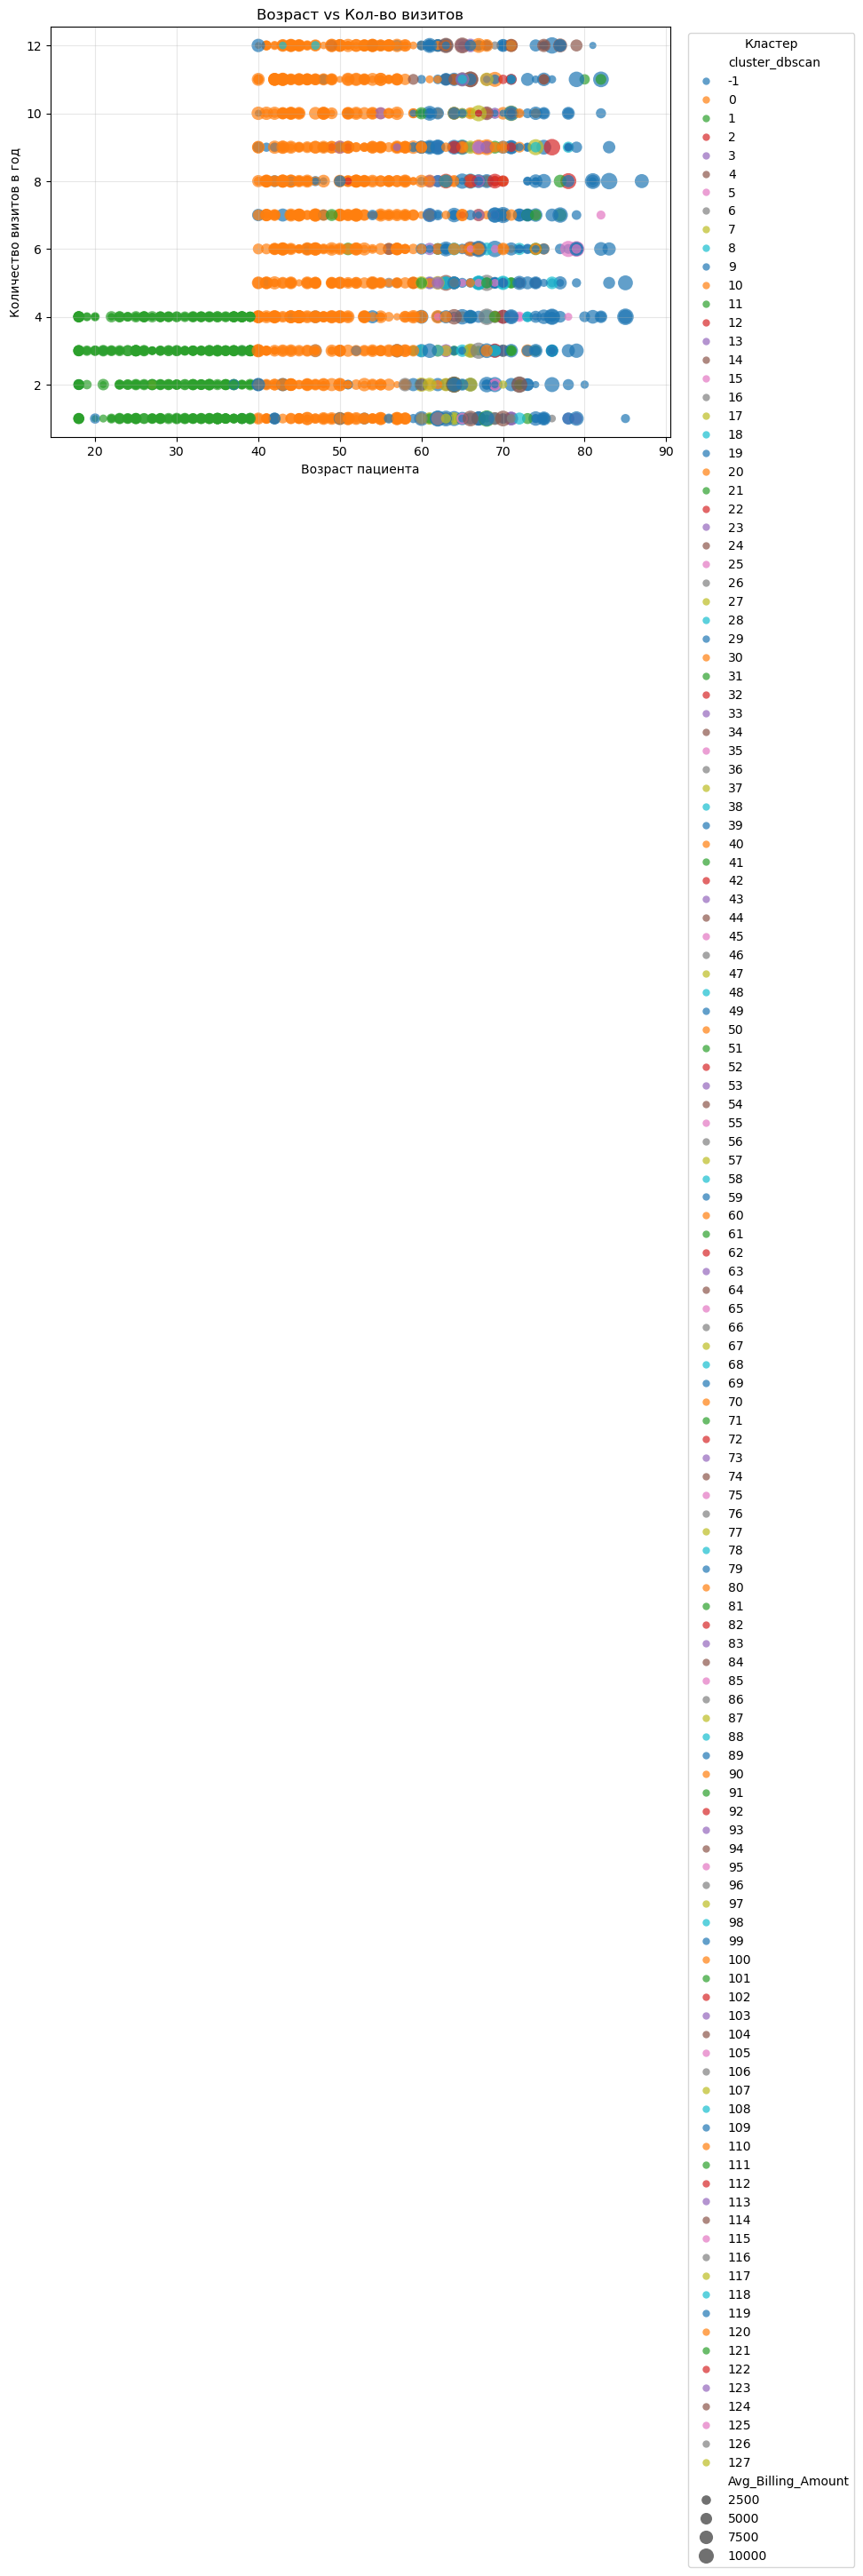

In [10]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Age',
    y='Annual_Visits',
    hue='cluster_dbscan',
    palette='tab10',
    size='Avg_Billing_Amount',          # размер точки = кол-во визитов
    sizes=(30, 180),               # диапазон размеров
    alpha=0.7,
    edgecolor='none'
)

plt.title("Возраст vs Кол-во визитов")
plt.xlabel("Возраст пациента")
plt.ylabel("Количество визитов в год")
plt.legend(title="Кластер", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### AgglomerativeClustering

Это метод иерархической кластеризации, который объединяет объекты в кластеры на основе их близости. Процесс кластеризации начинается с того, что изначально каждый объект считается отдельным кластером, а затем на каждом шаге два наиболее близких кластера сливаются в один, пока не будет достигнуто желаемое число кластеров или один общий кластер.

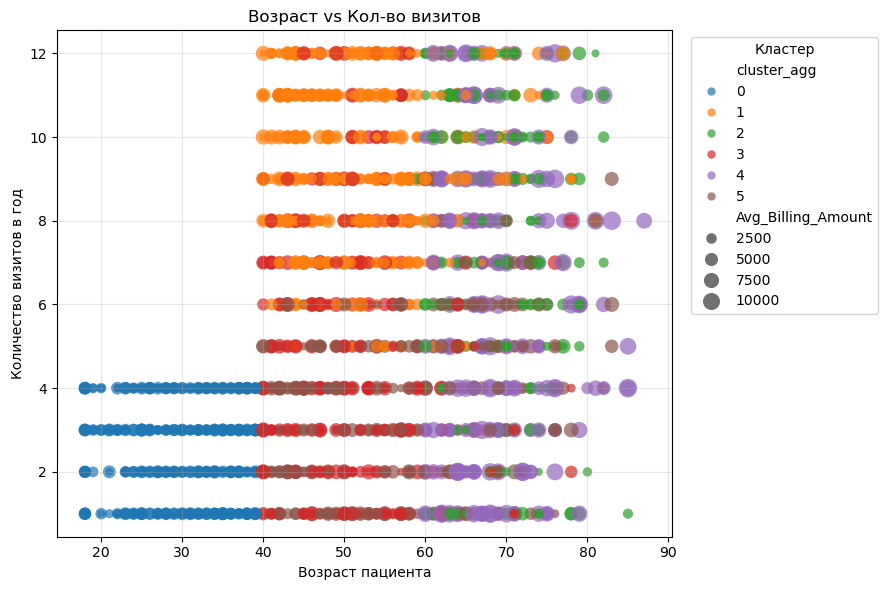

In [11]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Age',
    y='Annual_Visits',
    hue='cluster_agg',
    palette='tab10',
    size='Avg_Billing_Amount',          # размер точки = кол-во визитов
    sizes=(30, 180),               # диапазон размеров
    alpha=0.7,
    edgecolor='none'
)

plt.title("Возраст vs Кол-во визитов")
plt.xlabel("Возраст пациента")
plt.ylabel("Количество визитов в год")
plt.legend(title="Кластер", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

У каждого кластера получились разные графики, но в плане качества довольно похожи. Как я считаю, лучший график получился у DBSCAN.

### Вывод

Как мне кажется, самые лучшие результаты показал метод KMeans.

### Сохраним лучший метод

In [12]:
joblib.dump(kmeans, 'best_model.kpl')

['best_model.kpl']

In [13]:
df.to_csv('patient_segmentation_dataset_with_clusters.csv', index=False)